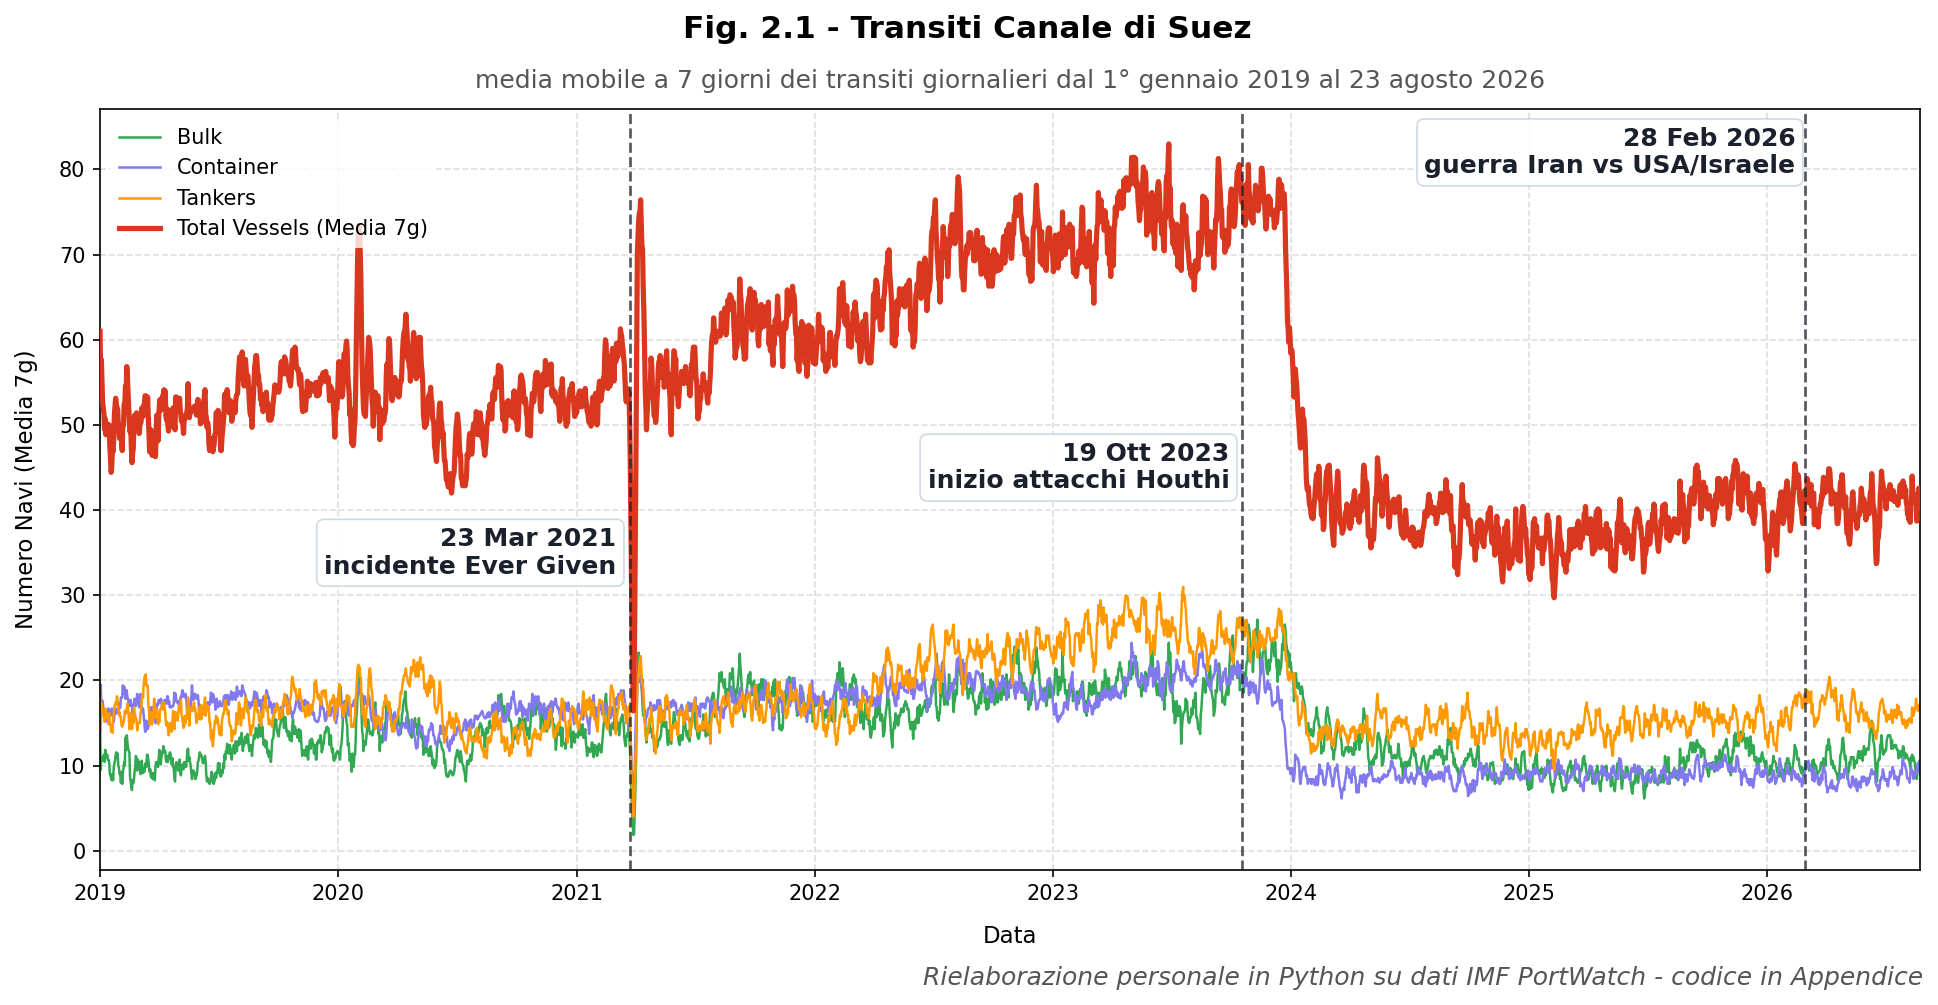

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# data
df = pd.read_csv('Vandelli_Suez_Daily_Chokepoints_Data.csv')
df = df.sort_values(by=['year', 'month', 'day']).reset_index(drop=True)
df['Date'] = pd.to_datetime(df[['year', 'month', 'day']])

# rolling avg
colonne = ['n_total', 'n_dry_bulk', 'n_container', 'n_tanker']
df_smooth = df.copy()
for col in colonne:
    df_smooth[col] = df[col].rolling(window=7, min_periods=1).mean()

# graph
plt.figure(figsize=(13, 6.5), dpi=150)

# vessels type
plt.plot(df_smooth['Date'], df_smooth['n_dry_bulk'], label='Bulk', color='#32a852', linewidth=1.2)
plt.plot(df_smooth['Date'], df_smooth['n_container'], label='Container', color='#8179ed', linewidth=1.2)
plt.plot(df_smooth['Date'], df_smooth['n_tanker'], label='Tankers', color='#ff9900', linewidth=1.2)

# total vessels
plt.plot(df_smooth['Date'], df_smooth['n_total'], label='Total Vessels (Media 7g)', color='#d9381e', linewidth=2.5, zorder=5)

# events and text
events = [
    {
        'date': '2021-03-23',
        'label': '23 Mar 2021\nincidente Ever Given',
        'y_pos': 35,
        'align': 'right',
        'x_offset': -20
    },
    {
        'date': '2023-10-19',
        'label': '19 Ott 2023\ninizio attacchi Houthi',
        'y_pos': 45,
        'align': 'right',
        'x_offset': -20
    },
    {
        'date': '2026-02-28',
        'label': '28 Feb 2026\nguerra Iran vs USA/Israele',
        'y_pos': 82,
        'align': 'right',
        'x_offset': -15
    }
]

for ev in events:
    date_dt = pd.to_datetime(ev['date'])

    # events vertical
    plt.axvline(x=date_dt, color='#1a202c', linestyle='--', linewidth=1.3, alpha=0.75, zorder=6)

    # events text
    x_pos = date_dt + pd.Timedelta(days=ev['x_offset'])
    plt.text(x_pos, ev['y_pos'], ev['label'],
             color='#1a202c', fontsize=12, fontweight='bold',
             horizontalalignment=ev['align'], verticalalignment='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#cbd5e0', alpha=0.9, linewidth=0.8),
             zorder=7)

# title
plt.suptitle('Fig. 2.1 - Transiti Canale di Suez', fontsize=15, fontweight='bold', y=0.98)
plt.title('media mobile a 7 giorni dei transiti giornalieri dal 1° gennaio 2019 al 23 agosto 2026', fontsize=12, color='#555555', pad=10)
plt.xlabel('Data', fontsize=11, labelpad=10)
plt.ylabel('Numero Navi (Media 7g)', fontsize=11, labelpad=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(frameon=True, facecolor='white', edgecolor='none', loc='upper left')
plt.tight_layout()
plt.xlim(df_smooth['Date'].min(), df_smooth['Date'].max())

# subtitle
plt.figtext(0.99, -0.02, 'Rielaborazione personale in Python su dati IMF PortWatch - codice in Appendice',
            ha='right', va='bottom', fontsize=12, color='#555555', fontstyle='italic')
plt.tight_layout()

# svg
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['path.simplify'] = False
plt.rcParams['path.simplify_threshold'] = 0.0

# export pdf
plt.savefig('grafico_suez.pdf', format='pdf', bbox_inches='tight')
plt.show()